<Universe with 3341 atoms>
98 frames
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97]


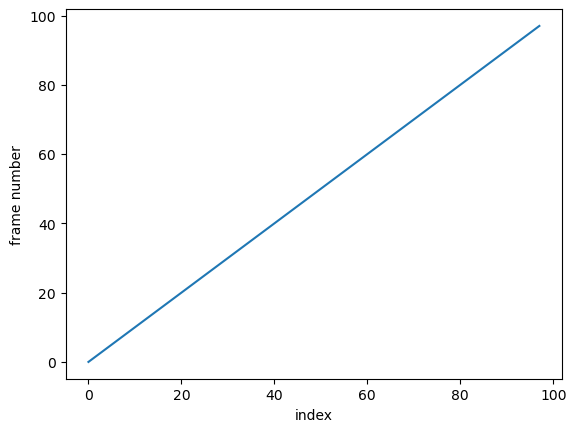

In [4]:
#MDAnalysis tutorial #0
import warnings
import MDAnalysis as mda
from MDAnalysis.tests.datafiles import PSF, DCD
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=DeprecationWarning) #show all warnings except DeprecationWarning(s)

u = mda.Universe(PSF,DCD)
print(u)
print(len(u.trajectory), "frames")

frames = [ts.frame for ts in u.trajectory]
print(frames)

plt.plot(frames)
plt.xlabel("index")
plt.ylabel("frame number")
plt.show()

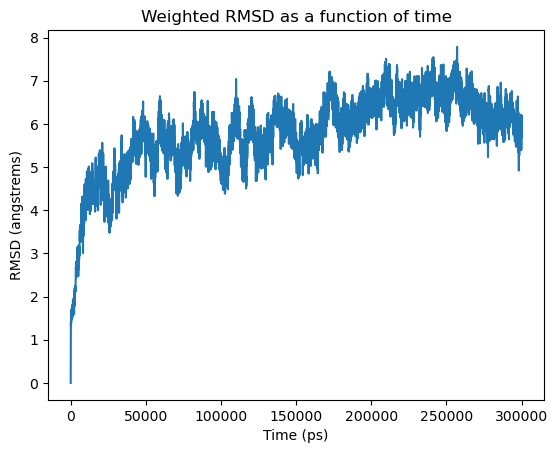

In [16]:
#MDAnalysis tutorial #1,2,3
import warnings
import MDAnalysis as mda
#from MDAnalysis.tests.datafiles import PSF, DCD
from MDAnalysis.analysis import rms
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=DeprecationWarning) #show all warnings except DeprecationWarning(s)

u = mda.Universe("./protein.gro", "protein_traj_1.xtc","protein_traj_2.xtc","protein_traj_3.xtc")
rmsd = rms.RMSD(u, select="name CA", weights='mass')
rmsd.run()
result = rmsd.results.rmsd

plt.plot(result[:,1],result[:,2])
plt.xlabel("Time (ps)")
plt.ylabel("RMSD (angstrems)")
plt.title("Weighted RMSD as a function of time")
plt.show()

In [14]:
#MDAnalysis tutorial #2 Spliting universe 
import warnings
import MDAnalysis as mda

warnings.filterwarnings("ignore", category=DeprecationWarning) #show all warnings except DeprecationWarning(s)

u = mda.Universe("./sys.gro","sys_md_aligned.xtc")
GTP = u.select_atoms("resname GTP")
GDP = u.select_atoms("resname GDP")
protein = u.select_atoms("protein")

GTP.write("./GTP.gro")
GDP.write("./GDP.gro")
protein.write("./protein.gro")

In [2]:
#MDAnalysis tutorial #2 Merging universe
import warnings
import MDAnalysis as mda

warnings.filterwarnings("ignore", category=DeprecationWarning) #show all warnings except DeprecationWarning(s)

protein = mda.Universe("./protein.gro")
GDP = mda.Universe("./GDP.gro")
GTP = mda.Universe("./GTP.gro")

merged = mda.Merge(protein.atoms, GDP.atoms, GTP.atoms)
merged.atoms.write("sys_merged_again.gro")

/home/yevhen/conda_envs/mdanalysis_tutorial/lib/python3.11/site-packages/MDAnalysis/coordinates/GRO.py:518: UserWarning: missing dimension - setting unit cell to zeroed box [0., 0., 0.]
  warnings.warn(wmsg)


In [13]:
#MDAnalysis tutorial #3 Trajecory operations
import warnings
import MDAnalysis as mda

warnings.filterwarnings("ignore", category=DeprecationWarning) #show all warnings except DeprecationWarning(s)

u = mda.Universe("./sys_merged_again.gro","sys_md_aligned.xtc")
n_frames = len(u.trajectory)
spliting_point = n_frames // 3

# First way to slice trajectory: AtomGroup -> write(filepath, frames=...)
#protein = u.select_atoms("protein")
#protein.write("protein_traj_1.xtc", frames=u.trajectory[:spliting_point])
#protein.write("protein_traj_2.xtc", frames=u.trajectory[spliting_point:spliting_point*2])
#protein.write("protein_traj_3.xtc", frames=u.trajectory[spliting_point*2:])

# Second way to slice trajectory: AtomGroup -> mda.Writer
ca = u.select_atoms("name CA")
with mda.Writer("ca_1.pdb", ca.n_atoms) as W:
    for ts in u.trajectory[:spliting_point]:
        W.write(ca)

with mda.Writer("ca_2.pdb", ca.n_atoms) as W:
    for ts in u.trajectory[spliting_point:spliting_point*2]:
        W.write(ca)

with mda.Writer("ca_3.pdb", ca.n_atoms) as W:
    for ts in u.trajectory[spliting_point*2:]:
        W.write(ca)

/home/yevhen/conda_envs/mdanalysis_tutorial/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn(
/home/yevhen/conda_envs/mdanalysis_tutorial/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn(
/home/yevhen/conda_envs/mdanalysis_tutorial/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'chainIDs' Using default value of ''
  warnings.warn(
/home/yevhen/conda_envs/mdanalysis_tutorial/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn(
/home/yevhen/conda_envs/mdanalysis_tutorial/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'tempfactors' 

In [10]:
#MDAnalysis tutorial #3 Atom selection language
import warnings
import MDAnalysis as mda

warnings.filterwarnings("ignore", category=DeprecationWarning) #show all warnings except DeprecationWarning(s)

u = mda.Universe("./5Y36.pdb")

#SIMPLE SELECTIONS
protein = u.select_atoms("protein")
backbone = u.select_atoms("backbone")
nucleic = u.select_atoms("nucleic")
nucleicbackbone = u.select_atoms("nucleicbackbone")
nucleicbase = u.select_atoms("nucleicbase")
nucleicsugar = u.select_atoms("nucleicsugar")
segid_A = u.select_atoms("segid A")
resid = u.select_atoms("resid 100A:200A")
resnum = u.select_atoms("resnum 200:300")
resname = u.select_atoms("resname CYS")
c_atoms = u.select_atoms("name C")
atom = u.select_atoms("atom A 2 CA")
altloc = u.select_atoms("altloc ?")
any_insertion = u.select_atoms("icode ?")
no_insertion = u.select_atoms("icode !?")

#BOOLEAN SELECTIONS
not_protein = u.select_atoms("not protein")
protein_and_not_CYS = u.select_atoms("protein and not resname CYS")
LYS_or_ARG = u.select_atoms("protein and (resname LYS or resname ARG)")
protein_or_nucleic = u.select_atoms("protein or nucleic")

#ATOM INDEX SELECTIONS
first_hundred = protein.select_atoms("index 0:99")
first_hundred_by_num = protein.select_atoms("bynum 1:100")

#EXAMINING RESULTING ATOM GROUPS
if first_hundred == first_hundred_by_num:
    print("only range changes when using index and/or bynum:)")

intersection = protein & nucleic
print("protein and nucleic atom groups do not intersect")

protein.write("5Y36_protein.pdb")
nucleic.write("5Y36_nucleic.pdb")

/home/yevhen/conda_envs/mdanalysis_tutorial/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:479: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn(
/home/yevhen/conda_envs/mdanalysis_tutorial/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(
/home/yevhen/conda_envs/mdanalysis_tutorial/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(


only range changes when using index and/or bynum:)
protein and nucleic atom groups do not intersect


In [ ]:
#MDAnalysis tutorial #4 Dynamic selections
import warnings
import MDAnalysis as mda

warnings.filterwarnings("ignore", category=DeprecationWarning) #show all warnings except DeprecationWarning(s)

u = mda.Universe("./sys_merged_again.gro","sys_md_aligned.xtc")

# GEOMETRICAL SELECTIONS
ag_around_GTP = u.select_atoms("around 6.0 resname GTP", updating=True)
ag_GTP_binding_site = u.select_atoms("(around 6.0 resname GTP) or resname GTP", updating=True)
ag_sphzone_GTP = u.select_atoms("sphzone 6.0 resname GTP", updating=True)
ag_sphlayer_GTP = u.select_atoms("sphlayer 6.0 3.0 resname GTP", updating=True)
ag_cyzone_GTP = u.select_atoms("cyzone 6.0 3.0 -3.0 resname GTP", updating=True)
ag_cylayer_GTP = u.select_atoms("cylayer 6.0 3.0 3.0 -3.0 resname GTP", updating=True)
ag_point = u.select_atoms("point 30.0 30.0 30.0 3.5", updating=True)
ag_prop = u.select_atoms("prop z >= 10.0", updating=True)

# SIMILARITY AND CONNECTIVITY
ag_same_as_GTP = u.select_atoms("same segid as resname GTP")
ag_byres = u.select_atoms("byres resname GTP")

# EXAMINING RESULTING ATOM GROUP
ag_around_GTP.write("GTP_binding_site_atoms.pdb")
ag_GTP_binding_site.write("GTP_in_binding_site.pdb")

n = 0
while u.trajectory.next():
    ag_GTP_binding_site.write(f"./gtp_binding_site/frame{n}.pdb")
    n += 1

/home/yevhen/conda_envs/mdanalysis_tutorial/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn(
/home/yevhen/conda_envs/mdanalysis_tutorial/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn(
/home/yevhen/conda_envs/mdanalysis_tutorial/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'chainIDs' Using default value of ''
  warnings.warn(
/home/yevhen/conda_envs/mdanalysis_tutorial/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn(
/home/yevhen/conda_envs/mdanalysis_tutorial/lib/python3.11/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'tempfactors' 